# Import Necessary Modules & Packages

In [ ]:
import os
import cv2
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# Parameter

In [ ]:
height = 224
widht = 224
channels = 3
batch_size = 16
img_shape = (height, widht, channels)
img_size = (height, widht)

epoch = 5
learning_rate = 0.001
sequence_length = 5

# Update dataset_path to use the downloaded path
dataset_path = os.path.join(path, 'raw_video/')

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("anggiyohanespardede/bisindo-40-kata-mp4")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'bisindo-40-kata-mp4' dataset.
Path to dataset files: /kaggle/input/bisindo-40-kata-mp4


# Transformations

In [ ]:
from torchvision import transforms, models
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(img_size),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Extract Frames from Video

In [ ]:
def extract_frames(video_path, sequence_length, interval=10, img_size=(224, 224)):
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print(f"Error opening video file {video_path}")
        return []

    frames = []
    frame_count = 0

    while len(frames) < sequence_length:
        ret, frame = cap.read()
        if not ret:
            break
        if frame_count % interval == 0:
            frame = cv2.resize(frame, img_size)
            frames.append(frame)
        frame_count += 1

    cap.release()

    if len(frames) < sequence_length:
        while len(frames) < sequence_length:
            if frames:
                frames.append(frames[-1])
            else:
                frames.append(cv2.resize(np.zeros((img_size[1], img_size[0], 3), dtype=np.uint8), img_size))
    else:
        frames = frames[:sequence_length]

    return frames

# Dataset

In [ ]:
class VideoDataset(Dataset):
    def __init__(self, video_files, labels, transform=None, sequence_length=10):
        self.video_files = video_files
        self.labels = labels
        self.transform = transform
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.video_files)

    def __getitem__(self, idx):
        frames = extract_frames(self.video_files[idx], self.sequence_length)
        if self.transform:
            frames = [self.transform(frame) for frame in frames]
        label = self.labels[idx]
        return torch.stack(frames), label

In [ ]:
def load_dataset(dataset_path, num_classes=40):
    video_files = []
    labels = []
    classes = sorted(os.listdir(dataset_path))[:num_classes]

    for label, class_name in enumerate(classes):
        class_path = os.path.join(dataset_path, class_name)
        if os.path.isdir(class_path):
            videos = os.listdir(class_path)
            for video_name in videos:
                video_path = os.path.join(class_path, video_name)
                video_files.append(video_path)
                labels.append(label)

    return video_files, labels, classes

In [ ]:
video_files, labels, classes = load_dataset(dataset_path)
train_video_files, val_video_files, train_labels, val_labels = train_test_split(video_files, labels, test_size=0.2, random_state=42)

In [ ]:
print(set(classes))

{'Duduk', 'Kemana', 'Marah', 'Pendek', 'Selamat Pagi', 'Mandi', 'Selamat Sore', 'Halo', 'Makan', 'Siapa', 'Kamu', 'Tinggi', 'Kalian', 'Berdiri', 'Kapan', 'Sedih', 'Minum', 'Selamat Siang', 'Belajar', 'Mereka', 'Apa', 'Baik', 'Saya', 'Menulis', 'Ramah', 'Terima Kasih', 'Kami', 'Melihat', 'Senang', 'Sabar', 'Apa Kabar', 'Bagaimana', 'Dimana', 'Membaca', 'Bingung', 'Selamat Malam', 'Tidur', 'Berapa', 'Dia', 'Kita'}


In [ ]:
train_dataset = VideoDataset(train_video_files, train_labels, transform=transform, sequence_length=sequence_length)
val_dataset = VideoDataset(val_video_files, val_labels, transform=transform, sequence_length=sequence_length)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

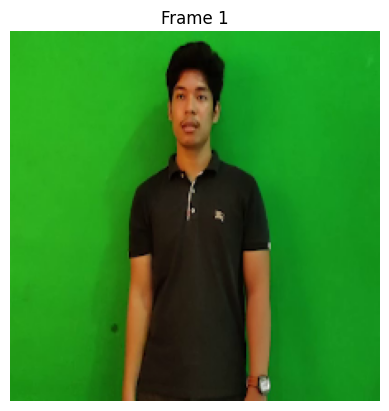

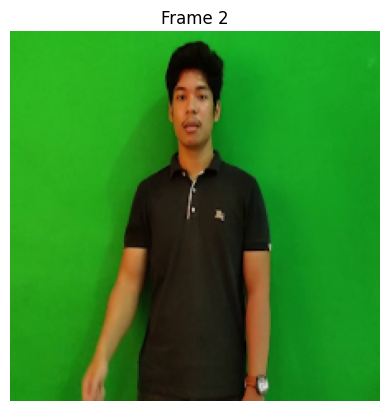

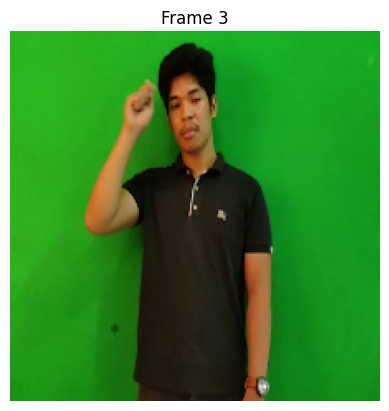

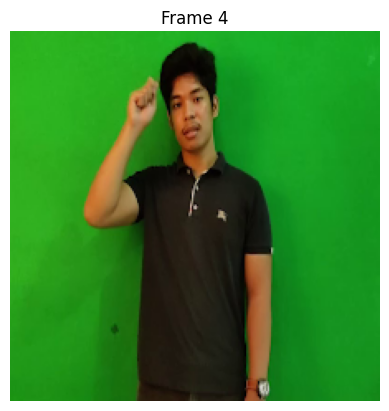

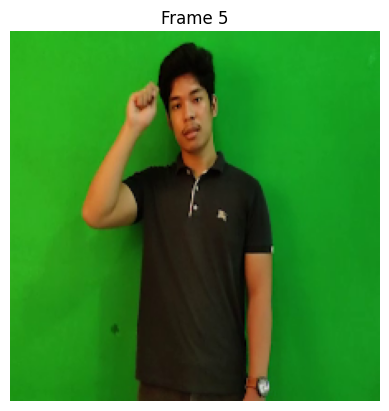

In [ ]:
video_path = train_video_files[0]
sequence_length = 5

# Ekstraksi frame
frames = extract_frames(video_path, sequence_length)

# Tampilkan setiap frame menggunakan matplotlib
for i, frame in enumerate(frames):
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.title(f'Frame {i+1}')
    plt.axis('off')
    plt.show()

# Model

In [ ]:
class BISINDOClassifier(nn.Module):
    def __init__(self, hidden_dim, num_classes, num_layers=1):
        super(BISINDOClassifier, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_classes = num_classes
        self.num_layers = num_layers

        # Load pre-trained VGG-19
        self.vgg19 = models.vgg19(pretrained=True)
        self.vgg19.classifier = nn.Sequential()

        # GRU
        self.gru = nn.GRU(input_size=512*7*7, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True)

        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        batch_size, seq_length, c, h, w = x.size()
        x = x.view(batch_size * seq_length, c, h, w)

        with torch.no_grad():
            x = self.vgg19.features(x)

        x = x.view(batch_size, seq_length, -1)

        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(x.device)
        x, _ = self.gru(x, h0)

        x = self.fc(x[:, -1, :])

        return x

In [ ]:
hidden_dim = 512
num_classes = len(set(labels))
model = BISINDOClassifier(hidden_dim, num_classes).to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:05<00:00, 104MB/s] 


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training

In [ ]:
def train_model(model, criterion, optimizer, train_loader, val_loader, num_epochs):
    train_loss_history = []
    train_acc_history = []
    val_loss_history = []
    val_acc_history = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)
        train_loss_history.append(epoch_loss)
        train_acc_history.append(epoch_acc)

        model.eval()
        val_running_loss = 0.0
        val_running_corrects = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)

                val_running_loss += loss.item() * inputs.size(0)
                val_running_corrects += torch.sum(preds == labels.data)

        val_epoch_loss = val_running_loss / len(val_loader.dataset)
        val_epoch_acc = val_running_corrects.double() / len(val_loader.dataset)
        val_loss_history.append(val_epoch_loss)
        val_acc_history.append(val_epoch_acc)

        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}, Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_acc:.4f}')

    return train_loss_history, train_acc_history, val_loss_history, val_acc_history

In [ ]:
train_loss_history, train_acc_history, val_loss_history, val_acc_history = train_model(model, criterion, optimizer, train_loader, val_loader, epoch)

Epoch 1/5, Loss: 1.7114, Acc: 0.7025, Val Loss: 0.6074, Val Acc: 0.9400
Epoch 2/5, Loss: 0.2663, Acc: 0.9825, Val Loss: 0.1808, Val Acc: 0.9850
Epoch 3/5, Loss: 0.0745, Acc: 0.9988, Val Loss: 0.0783, Val Acc: 0.9925
Epoch 4/5, Loss: 0.0296, Acc: 0.9994, Val Loss: 0.0623, Val Acc: 0.9900
Epoch 5/5, Loss: 0.0179, Acc: 0.9994, Val Loss: 0.0509, Val Acc: 0.9900


# Evaluate

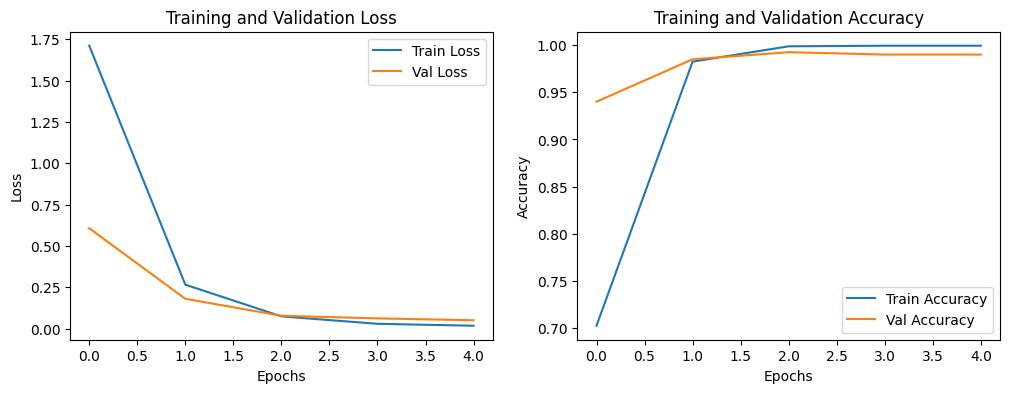

In [ ]:
import matplotlib.pyplot as plt

# Convert the history lists from GPU to CPU and then to numpy arrays
train_loss_history_np = [loss.cpu().numpy() if torch.is_tensor(loss) else loss for loss in train_loss_history]
val_loss_history_np = [loss.cpu().numpy() if torch.is_tensor(loss) else loss for loss in val_loss_history]
train_acc_history_np = [acc.cpu().numpy() if torch.is_tensor(acc) else acc for acc in train_acc_history]
val_acc_history_np = [acc.cpu().numpy() if torch.is_tensor(acc) else acc for acc in val_acc_history]

# Define the range of epochs
epochs_range = range(len(train_loss_history_np))

# Plotting
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss_history_np, label='Train Loss')
plt.plot(epochs_range, val_loss_history_np, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_acc_history_np, label='Train Accuracy')
plt.plot(epochs_range, val_acc_history_np, label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.show()

In [ ]:
def preprocess_frames(frames):
    frames = [transform(frame) for frame in frames]
    frames = torch.stack(frames)
    return frames.unsqueeze(0)

In [ ]:
def predict(video_path, sequence_length):
    model.eval()

    frames = extract_frames(video_path, sequence_length)
    input_tensor = preprocess_frames(frames)
    input_tensor = input_tensor.to(device)

    # Prediksi menggunakan model
    with torch.no_grad():
        output = model(input_tensor)
        _, predicted = torch.max(output, 1)

    predicted_label = classes[predicted.item()]
    return predicted_label

In [ ]:
video_path = '/kaggle/input/bisindo-40-kata-mp4/raw_video/Apa Kabar/BISINDO_Apa Kabar_023.mp4'
sequence_length = 5

predict(video_path, sequence_length)

'Apa Kabar'

# Saving the Model

In [ ]:
print("The state dict keys: \n\n", model.state_dict().keys())

The state dict keys: 

 odict_keys(['vgg19.features.0.weight', 'vgg19.features.0.bias', 'vgg19.features.2.weight', 'vgg19.features.2.bias', 'vgg19.features.5.weight', 'vgg19.features.5.bias', 'vgg19.features.7.weight', 'vgg19.features.7.bias', 'vgg19.features.10.weight', 'vgg19.features.10.bias', 'vgg19.features.12.weight', 'vgg19.features.12.bias', 'vgg19.features.14.weight', 'vgg19.features.14.bias', 'vgg19.features.16.weight', 'vgg19.features.16.bias', 'vgg19.features.19.weight', 'vgg19.features.19.bias', 'vgg19.features.21.weight', 'vgg19.features.21.bias', 'vgg19.features.23.weight', 'vgg19.features.23.bias', 'vgg19.features.25.weight', 'vgg19.features.25.bias', 'vgg19.features.28.weight', 'vgg19.features.28.bias', 'vgg19.features.30.weight', 'vgg19.features.30.bias', 'vgg19.features.32.weight', 'vgg19.features.32.bias', 'vgg19.features.34.weight', 'vgg19.features.34.bias', 'gru.weight_ih_l0', 'gru.weight_hh_l0', 'gru.bias_ih_l0', 'gru.bias_hh_l0', 'fc.weight', 'fc.bias'])


In [ ]:
checkpoint = {'model': model,
              'state_dict': model.state_dict(),
              'optimizer' : optimizer.state_dict()}

torch.save(checkpoint, 'checkpoint.pth')

In [ ]:
def load_checkpoint(filepath):
    checkpoint = torch.load(filepath)
    model = checkpoint['model']
    model.load_state_dict(checkpoint['state_dict'])
    for parameter in model.parameters():
        parameter.requires_grad = False

    model.eval()

    return model

In [ ]:
# Setelah selesai melatih model
model_path = 'model.pth'
torch.save(model.state_dict(), model_path)
print(f'Model saved to {model_path}')

Model saved to model.pth
